In [8]:
# CUDA_VISIBLE_DEVICES="" python /mnt/sunxh/sunxh/TandemMod/scripts/TandemMod.py --run_mode test \
#      --pretrained_model /mnt/sunxh/sunxh/benchmark/model/m6A.IVET.pkl \
#      --test_data_mod /mnt/sunxh/sunxh/benchmark/rna002-ivt/features/IVT_m6A.feature.tsv \
#      --test_data_unmod /mnt/sunxh/sunxh/benchmark/rna002-ivt/features/IVT_normalA.feature.tsv


In [9]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ===== 0) 你的文件路径（原样粘贴）=====
FILES = [
"/mnt/sunxh/sunxh/project/ipynb_result/directRM.m1a.pr.csv",
"/mnt/sunxh/sunxh/project/ipynb_result/directRM.m1a.roc.csv",
"/mnt/sunxh/sunxh/project/ipynb_result/directRM.m5c.pr.csv",
"/mnt/sunxh/sunxh/project/ipynb_result/directRM.m5c.roc.csv",
"/mnt/sunxh/sunxh/project/ipynb_result/directRM.m6a.pr.csv",
"/mnt/sunxh/sunxh/project/ipynb_result/directRM.m6a.roc.csv",
"/mnt/sunxh/sunxh/project/ipynb_result/directRM.m7g.pr.csv",
"/mnt/sunxh/sunxh/project/ipynb_result/directRM.m7g.roc.csv",
"/mnt/sunxh/sunxh/project/ipynb_result/directRM.psi.pr.csv",
"/mnt/sunxh/sunxh/project/ipynb_result/directRM.psi.roc.csv",
"/mnt/sunxh/sunxh/project/ipynb_result/singlemod.m6a.pr.csv",
"/mnt/sunxh/sunxh/project/ipynb_result/singlemod.m6a.roc.csv",
"/mnt/sunxh/sunxh/project/ipynb_result/TandemMod.A-to-I.pr_curve.csv",
"/mnt/sunxh/sunxh/project/ipynb_result/TandemMod.A-to-I.roc_curve.csv",
"/mnt/sunxh/sunxh/project/ipynb_result/TandemMod.hm5C.pr_curve.csv",
"/mnt/sunxh/sunxh/project/ipynb_result/TandemMod.hm5C.roc_curve.csv",
"/mnt/sunxh/sunxh/project/ipynb_result/TandemMod.m1A.pr_curve.csv",
"/mnt/sunxh/sunxh/project/ipynb_result/TandemMod.m1A.roc_curve.csv",
"/mnt/sunxh/sunxh/project/ipynb_result/TandemMod.m5c.pr_curve.csv",
"/mnt/sunxh/sunxh/project/ipynb_result/TandemMod.m5c.roc_curve.csv",
"/mnt/sunxh/sunxh/project/ipynb_result/TandemMod.m6a.pr_curve.csv",
"/mnt/sunxh/sunxh/project/ipynb_result/TandemMod.m6a.roc_curve.csv",
"/mnt/sunxh/sunxh/project/ipynb_result/TandemMod.m7G.pr_curve.csv",
"/mnt/sunxh/sunxh/project/ipynb_result/TandemMod.m7G.roc_curve.csv",
"/mnt/sunxh/sunxh/project/ipynb_result/TandemMod.psU.pr_curve.csv",
"/mnt/sunxh/sunxh/project/ipynb_result/TandemMod.psU.roc_curve.csv",
"/mnt/sunxh/sunxh/project/ipynb_result/tombo.m5c.pr.csv",
"/mnt/sunxh/sunxh/project/ipynb_result/tombo.m5c.roc.csv",
"/mnt/sunxh/sunxh/project/ipynb_result/tombo.m6a.pr.csv",
"/mnt/sunxh/sunxh/project/ipynb_result/tombo.m6a.roc.csv",
"/mnt/sunxh/sunxh/project/ipynb_result/wattmamod.hm5c.pr.csv",
"/mnt/sunxh/sunxh/project/ipynb_result/wattmamod.hm5c.roc.csv",
"/mnt/sunxh/sunxh/project/ipynb_result/wattmamod.inosine.pr.csv",
"/mnt/sunxh/sunxh/project/ipynb_result/wattmamod.inosine.roc.csv",
"/mnt/sunxh/sunxh/project/ipynb_result/wattmamod.m1a.pr.csv",
"/mnt/sunxh/sunxh/project/ipynb_result/wattmamod.m1a.roc.csv",
"/mnt/sunxh/sunxh/project/ipynb_result/wattmamod.m5c.pr.csv",
"/mnt/sunxh/sunxh/project/ipynb_result/wattmamod.m5c.roc.csv",
"/mnt/sunxh/sunxh/project/ipynb_result/wattmamod.m6a.pr.csv",
"/mnt/sunxh/sunxh/project/ipynb_result/wattmamod.m6a.roc.csv",
"/mnt/sunxh/sunxh/project/ipynb_result/wattmamod.m7g.pr.csv",
"/mnt/sunxh/sunxh/project/ipynb_result/wattmamod.m7g.roc.csv",
"/mnt/sunxh/sunxh/project/ipynb_result/wattmamod.psu.pr.csv",
"/mnt/sunxh/sunxh/project/ipynb_result/wattmamod.psu.roc.csv",
"/mnt/sunxh/sunxh/project/ipynb_result/m6anet.m6a.pr.csv",
"/mnt/sunxh/sunxh/project/ipynb_result/m6anet.m6a.roc.csv",
"/mnt/sunxh/sunxh/project/ipynb_result/nanom6a.m6a.pr.csv",
"/mnt/sunxh/sunxh/project/ipynb_result/nanom6a.m6a.roc.csv",
"/mnt/sunxh/sunxh/project/ipynb_result/orca.hm5c.pr.csv",
"/mnt/sunxh/sunxh/project/ipynb_result/orca.hm5c.roc.csv",
"/mnt/sunxh/sunxh/project/ipynb_result/orca.m1a.pr.csv",
"/mnt/sunxh/sunxh/project/ipynb_result/orca.m1a.roc.csv",
"/mnt/sunxh/sunxh/project/ipynb_result/orca.m5c.pr.csv",
"/mnt/sunxh/sunxh/project/ipynb_result/orca.m5c.roc.csv",
"/mnt/sunxh/sunxh/project/ipynb_result/orca.m6a.pr.csv",
"/mnt/sunxh/sunxh/project/ipynb_result/orca.m6a.roc.csv",
"/mnt/sunxh/sunxh/project/ipynb_result/orca.m7g.pr.csv",
"/mnt/sunxh/sunxh/project/ipynb_result/orca.m7g.roc.csv",
"/mnt/sunxh/sunxh/project/ipynb_result/orca.psu.pr.csv",
"/mnt/sunxh/sunxh/project/ipynb_result/orca.psu.roc.csv",
"/mnt/sunxh/sunxh/project/ipynb_result/orca.inosine.roc.csv",
"/mnt/sunxh/sunxh/project/ipynb_result/orca.inosine.pr.csv"

]

# ===== 1) 目标维度顺序（你要求的）=====
DIMS = ["m6a","m5c","m1a","psu","hm5c","m7g","inosine"]
DIM_SHOW = ["m6A","m5C","m1A","psU","hm5C","m7G","Inosine"]

# 统一修饰名
MOD_MAP = {
    "m6a":"m6a","m5c":"m5c","m1a":"m1a","m7g":"m7g",
    "psu":"psu","psi":"psu","psu.":"psu","psu_":"psu",
    "hm5c":"hm5c",
    "inosine":"inosine","a-to-i":"inosine","a_to_i":"inosine",
}

def canon_mod(s: str):
    s = s.lower().strip()
    s = s.replace("_","-")
    return MOD_MAP.get(s, None)

def auc_trapz(x, y):
    x = np.asarray(x, float)
    y = np.asarray(y, float)
    m = np.isfinite(x) & np.isfinite(y)
    x, y = x[m], y[m]
    if x.size < 2: return np.nan
    idx = np.argsort(x)
    x, y = x[idx], y[idx]
    # 去重 x
    ux, uidx = np.unique(x, return_index=True)
    y = y[uidx]
    if ux.size < 2: return np.nan
    return float(np.trapz(y, ux))

def norm_col(c: str) -> str:
    c = str(c).strip().lower()
    c = re.sub(r"[^a-z0-9]+", "_", c)   # 空格/括号/连字符 全部变 _
    c = c.strip("_")
    return c

def infer_roc_cols(cols):
    cols = [norm_col(c) for c in cols]
    # x: fpr, y: tpr
    fpr_cand = ["fpr","false_positive_rate","fp_rate","one_minus_specificity","1_specificity","1_minus_specificity"]
    tpr_cand = ["tpr","true_positive_rate","tp_rate","sensitivity","recall"]
    fpr = next((c for c in fpr_cand if c in cols), None)
    tpr = next((c for c in tpr_cand if c in cols), None)
    return fpr, tpr

def infer_pr_cols(cols):
    cols = [norm_col(c) for c in cols]
    # x: recall, y: precision
    r_cand = ["recall","tpr","true_positive_rate"]
    p_cand = ["precision","prec","ppv"]
    r = next((c for c in r_cand if c in cols), None)
    p = next((c for c in p_cand if c in cols), None)
    return r, p

def compute_auc(fp: Path, metric: str):
    # 自动识别分隔符（逗号/tab/空格/分号都行）
    df = pd.read_csv(fp, sep=None, engine="python")
    df.columns = [str(c).strip().lower() for c in df.columns]

    # 你文件里明确有 roc_auc / pr_auc
    key = "roc_auc" if metric == "roc" else "pr_auc"
    if key in df.columns:
        v = pd.to_numeric(df[key], errors="coerce").dropna()
        if len(v) > 0:
            return float(v.iloc[0])

    # 兼容一些可能的命名
    alt = ["auc", "auroc", "auprc", "average_precision", "ap"]
    for k in alt:
        if k in df.columns:
            v = pd.to_numeric(df[k], errors="coerce").dropna()
            if len(v) > 0:
                return float(v.iloc[0])

    return np.nan



# ===== 2) 从文件名解析 model / mod / metric =====
pat = re.compile(r"^(?P<model>[^.]+)\.(?P<mod>[^.]+)\.(?P<metric>roc|pr)(?:_curve)?\.csv$", re.I)

rows = []
for f in FILES:
    fp = Path(f)
    m = pat.match(fp.name)
    if not m:
        continue
    model = m.group("model")
    mod_raw = m.group("mod")
    metric = m.group("metric").lower()
    mod = canon_mod(mod_raw)
    if mod is None:
        continue

    auc = compute_auc(fp, metric)
    rows.append([model, mod, metric, auc, str(fp)])

df_auc = pd.DataFrame(rows, columns=["model","mod","metric","auc","file"])
df_auc.to_csv(Path(FILES[0]).parent / "auc_table.csv", index=False)
bad = df_auc[df_auc["auc"].isna()]
print("AUC=NaN 的条目数：", bad.shape[0])
if bad.shape[0] > 0:
    print(bad[["model","mod","metric","file"]].to_string(index=False))

MISSING_AUC = 0.2



AUC=NaN 的条目数： 0


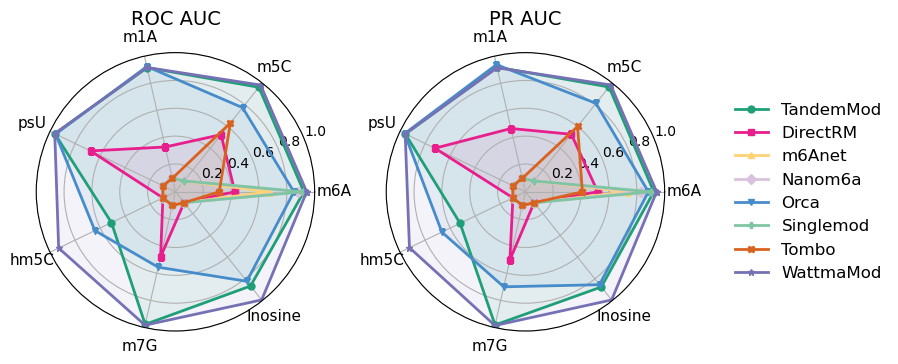

In [10]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# ===== 缺失值替代 =====
MISSING_AUC = 0.1

# ===== 你指定的 5 个 RGB 颜色 =====
RGB_LIST = [
    (118, 113, 180),  # 1
    (31, 159, 120),   # 2
    (232, 30, 141),   # 3
    (218, 98, 33),    # 4
    (128, 197, 162),  # 5
    (217,194,221),
    (255,211,115),
    (70, 140, 202)
    
]
COLORS = [(r/255, g/255, b/255) for r, g, b in RGB_LIST]

# ===== 每条线不同 marker / hatch =====
MARKERS = ["o", "s", "^", "D", "v", "P", "X", "*", "+", "x", "<", ">", "h", "H", "p"]
HATCHES = ["", "/", "\\", "|", "-", "+", "x", "o", "O", ".", "*"]

def canon_model(name: str) -> str:
    return str(name).strip().lower()

# ===== 显示名：WattmaMod 特殊处理；其余首字母大写；保留常见内部大写 =====
_PRETTY_MAP = {
    "wattmamod": "WattmaMod",
    "tandemmod": "TandemMod",
    "directrm":  "DirectRM",
    "tombo":     "Tombo",
    "singlemod": "Singlemod",
    "nanom6a":   "Nanom6a",
    "m6anet":    "m6Anet",
    "orca":      "Orca",
}
def pretty_model(name: str) -> str:
    k = canon_model(name)
    if k in _PRETTY_MAP:
        return _PRETTY_MAP[k]
    s = str(name).strip()
    return s[:1].upper() + s[1:] if s else s

# ===== 颜色映射：WattmaMod 用第一个颜色；其余按你给的颜色顺序分配，新增工具复用颜色 =====
MODEL2COLOR = {
    "wattmamod": COLORS[0],  # 强制第一个颜色
    "tandemmod": COLORS[1],
    "directrm":  COLORS[2],
    "tombo":     COLORS[3],
    "singlemod": COLORS[4],
    "nanom6a":   COLORS[5],
    "m6anet":    COLORS[6],
    "orca":      COLORS[7],
}

def _draw_radar_on_ax(ax, metric: str, title: str, df_auc, DIMS, DIM_SHOW):
    pivot = df_auc[df_auc["metric"] == metric].pivot_table(
        index="model", columns="mod", values="auc", aggfunc="max"
    )

    N = len(DIMS)
    angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
    angles += angles[:1]

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(DIM_SHOW, fontsize=11)

    ax.set_ylim(0.0, 1.0)
    ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_yticklabels(["0.2", "0.4", "0.6", "0.8", "1.0"], fontsize=10)
    ax.grid(True)

    for i, model in enumerate(pivot.index):
        vals = []
        for d in DIMS:
            v = pivot.loc[model, d] if d in pivot.columns else np.nan
            if not np.isfinite(v):
                v = MISSING_AUC
            vals.append(float(np.clip(v, 0.0, 1.0)))
        vals += vals[:1]

        mk = MARKERS[i % len(MARKERS)]
        hatch = HATCHES[i % len(HATCHES)]

        key = canon_model(model)
        c = MODEL2COLOR.get(key, COLORS[i % len(COLORS)])  # 不在映射就循环使用

        disp = pretty_model(model)
        line, = ax.plot(
            angles, vals,
            linewidth=2,
            marker=mk, markersize=5,
            label=disp,
            color=c
        )
        # 填充：同色 + hatch；不手动改其它颜色
        poly = ax.fill(angles, vals, alpha=0.08, facecolor=line.get_color())[0]


    ax.set_title(title, fontsize=14, pad=20)

def radar_2in1(out_pdf: Path,
               df_auc,
               DIMS,
               DIM_SHOW,
               figsize=(14, 7),
               png_dpi=1200):
    fig, axes = plt.subplots(
        1, 2,
        figsize=figsize,
        subplot_kw={"polar": True},
        constrained_layout=True
    )
    _draw_radar_on_ax(axes[0], "roc", "ROC AUC", df_auc, DIMS, DIM_SHOW)
    _draw_radar_on_ax(axes[1], "pr",  "PR AUC",  df_auc, DIMS, DIM_SHOW)
    handles, labels = axes[1].get_legend_handles_labels()
    fig.legend(handles, labels, loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False, fontsize=12)
    out_pdf = Path(out_pdf)
    fig.savefig(out_pdf, format="pdf", bbox_inches="tight", dpi=1200)
    plt.show()
    plt.close(fig)

out_dir = Path(FILES[0]).parent
radar_2in1(out_dir / "radar_roc_pr_auc_2in1.pdf", df_auc=df_auc, DIMS=DIMS, DIM_SHOW=DIM_SHOW, figsize=(7, 5))